## GSEA analysis + Escape analysis for pathways 

In this notebook we use GO and KEGG terms to profile changes in pathways between the following cohorts:
- CIAO
- UKBB
- SWISS100
- New England Centenerian Study (NECS)

Approach:
0) Lists of differentially abundant proteins are already computed (cent vs control in CIAO, cent vs healthy in SWISS100, cent vs controls in NECS) + for UKBB 
1) Using GO gene set (GO_BIOLOGICAL_PROCESS = "GO_Biological_Process_2023") and KEGG database (KEGG_HUMAN = "KEGG_2021_Human") we will get pathways'-related genes. Then, for each pathway, a normalized enrichment score (NES) will be computed: separately for the UK Biobank aging direction (using Age_Beta as the ranking metric) and the centenarian direction (using Log2FC).
2) Pathways were classified as "escape" if the aging NES and centenarian NES had opposing signs. Statistical significance was assessed using permutation-based p-values with Benjamini-Hochberg correction. Pathway enrichment of differentially expressed proteins was also performed using Fisher's exact test with KEGG and Hallmark gene sets.

In [13]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy
from pathlib import Path

PROJECT_ROOT = "/Users/achechenina/projects/centenerians"
PADJ_THRESH = 0.05
LOG2FC_THRESH = 0.5

### Data prep

In [14]:
# reading ciao full DE results
ciao_full = pd.read_csv(Path(PROJECT_ROOT) / "results" / "data" / "DE_basic" / "DE_basic_full.csv")
print(ciao_full.shape) 
ciao_full.head(3)

(5208, 7)


,PG.ProteinGroups,PG.Genes,PG.ProteinDescriptions,PG.ProteinNames,log2FC,pvalue,padj
0,A0A024R1R8;Q9Y2S6,TMA7B;TMA7,Translation machinery-associated protein 7B;Tr...,TMA7B_HUMAN;TMA7_HUMAN,0.170532,0.243082,0.399738
1,A0A024RBG1;Q9NZJ9,NUDT4B;NUDT4,Diphosphoinositol polyphosphate phosphohydrola...,NUD4B_HUMAN;NUDT4_HUMAN,0.044471,0.800222,0.875457
2,A0A075B6H7;A0A0C4DH55,IGKV3-7;IGKV3D-7,Probable non-functional immunoglobulin kappa v...,KV37_HUMAN;KVD07_HUMAN,1.277678,0.000190,0.003921


In [15]:
# reading ukbb betas
ukbb_full = pd.read_csv(Path(PROJECT_ROOT) / "results" / "data" / "ukbb_gene_name_preprocessed_full.csv")
print(ukbb_full.shape)
ukbb_full.head(3)

(2729, 18)


,ProteinID,Protein_name,Age_Beta,Age_SE,Age_log10p,Sex_Beta,Sex_SE,Sex_log10p,BMI_Beta,BMI_SE,BMI_log10p,Gene,Age_pvalue,Age_significant,Age_direction,gene_symbol_match,protein_id_stem,uniprot_id
0,AARSD1:Q9BTE6:OID21311:v1,Alanyl-tRNA editing protein Aarsd1,0.010334,0.000526,84.782401,0.283179,0.008432,243.876739,0.010647,0.000883,32.680552,AARSD1,1.650439e-85,True,increase,AARSD1,AARSD1,Q9BTE6
1,ABHD14B:Q96IU4:OID20921:v1,Protein ABHD14B,0.005952,0.000550,26.526876,0.115106,0.008811,38.210116,0.014309,0.000925,53.121683,ABHD14B,2.972514e-27,True,increase,ABHD14B,ABHD14B,Q96IU4
2,ABL1:P00519:OID21280:v1,Tyrosine-protein kinase ABL1,0.004479,0.000538,16.064501,0.040021,0.008619,5.463773,0.027441,0.000903,200.300619,ABL1,8.619828e-17,True,increase,ABL1,ABL1,P00519


In [16]:
# reading necs full DE results
necs_full = pd.read_csv(Path(PROJECT_ROOT) / "data/New_England_Sebastiani/cent2cont_table.csv")
print(necs_full.shape)
necs_full.head(3)

(4785, 11)


,SomaID,uniprot,geneID,FC.cont2cent,FC.off2cent,F.test,Pval.Ftest,Adj.Pvalue,Gene,log2FC.cent2cont,log2FC.cent2off
0,14042-11_3,Q8N474,SFRP1,0.299923,0.271781,115.233152,7.910000e-35,3.784940e-31,SFRP1,1.737338,1.879484
1,3045-72_2,P21246,PTN,0.424080,0.412717,112.182511,3.880000e-34,9.282900e-31,PTN,1.237592,1.276775
2,9756-6_3,Q01995,TAGLN,0.455853,0.407945,94.386544,2.740000e-30,4.370300e-27,TAGLN,1.133361,1.293553


In [5]:
# reading swiss100 full DE results
swiss100_full = pd.read_excel(
    Path(PROJECT_ROOT) / "data" / "SWISS100" / "acel70409-sup-0005-tables2.xlsx",
    sheet_name="2.a Centenarian - Healthy",
    index_col=0
)
swiss100_full['Gene'] = swiss100_full['Assay']
print(swiss100_full.shape)
swiss100_full.head(3)


(724, 12)


,Assay,OlinkID,UniProt,Panel,term,contrast,log2FoldChange,conf.low,conf.high,Adjusted_pval,Threshold,Gene
1,ACTA2,OID20079,P62736,Cardiometabolic,Group,Centenarian - Healthy,1.987067,1.635890,2.338244,1.000000e-16,Significant,ACTA2
2,ACTN4,OID20435,O43707,Inflammation,Group,Centenarian - Healthy,1.606815,1.234023,1.979607,1.000000e-16,Significant,ACTN4
3,ADA2,OID20394,Q9NZK5,Cardiometabolic,Group,Centenarian - Healthy,1.144260,0.865822,1.422697,1.000000e-16,Significant,ADA2


In [9]:
meta_dict = {'ciao': {'data': ciao_full, 'genecol': 'PG.Genes', 'log2fc_col': 'log2FC', 'padj_col': 'padj'}, # centenarian vs control
            'ukbb': {'data': ukbb_full, 'genecol': 'Gene', 'log2fc_col': 'Age_Beta', 'padj_col': 'Age_pvalue'}, # betas for age variable
            'necs': {'data': necs_full, 'genecol': 'Gene', 'log2fc_col': 'log2FC.cent2cont', 'padj_col': 'Adj.Pvalue'}, # centenarian vs control, not offspring
            'swiss100': {'data': swiss100_full, 'genecol': 'Gene', 'log2fc_col': 'log2FoldChange', 'padj_col': 'Adjusted_pval'}} # centenarian vs healthy, not geriatric

### Pathways annotation

General functions, setup for the following gene sets:
1. KEGG_LEGACY:
   1. Link: https://www.gsea-msigdb.org/gsea/msigdb/human/genesets.jsp?collection=CP:KEGG_LEGACY 
   2. Path: `/Users/achechenina/projects/centenerians/sanju_version/1_raw_data/kegg_pathways.gmt`
2. HALLMARK:
   1. Link: https://www.gsea-msigdb.org/gsea/msigdb/human/genesets.jsp?collection=H 
   2. Path: `/Users/achechenina/projects/centenerians/sanju_version/1_raw_data/hallmark_pathways.gmt`
3. GO Biological Processes:
   1. Link: https://www.gsea-msigdb.org/gsea/msigdb/human/genesets.jsp?collection=GO:BP 
   2. Path: `/Users/achechenina/projects/centenerians/data/c5.go.bp.v2026.1.Hs.symbols.gmt`
4. GO Molecular Function:
   1. Link: https://www.gsea-msigdb.org/gsea/msigdb/human/genesets.jsp?collection=GO:MF
   2. Path: `/Users/achechenina/projects/centenerians/data/c5.go.mf.v2026.1.Hs.symbols.gmt`

Gene sets prep:

In [11]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# KEGG + Hallmark gene lists from MSigDB-style GMT files (sanju raw data)
GMT_KEGG = Path(PROJECT_ROOT) / "sanju_version" / "1_raw_data" / "kegg_pathways.gmt"
GMT_HALLMARK = Path(PROJECT_ROOT) / "sanju_version" / "1_raw_data" / "hallmark_pathways.gmt"
GMT_GO_BP = Path(PROJECT_ROOT) / "data" / "c5.go.bp.v2026.1.Hs.symbols.gmt"
GMT_GO_MF = Path(PROJECT_ROOT) / "data" / "c5.go.mf.v2026.1.Hs.symbols.gmt"

def _parse_gmt(path: Path) -> dict[str, list[str]]:
    out: dict[str, list[str]] = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue
            name = parts[0]
            genes = [g for g in parts[2:] if g]
            out[name] = genes
    return out


KEGG_GMT = _parse_gmt(GMT_KEGG)
HALLMARK_GMT = _parse_gmt(GMT_HALLMARK)
GO_BP_GMT = _parse_gmt(GMT_GO_BP)
GO_MF_GMT = _parse_gmt(GMT_GO_MF)

# Output dirs (GSEA prerank NES tables + Fisher dotplots)
DATA_OUT = Path(PROJECT_ROOT) / "results" / "data" / "pathway_gsea_compare"
PLOT_OUT = Path(PROJECT_ROOT) / "results" / "plots" / "pathway_gsea_compare"
DATA_OUT.mkdir(parents=True, exist_ok=True)
PLOT_OUT.mkdir(parents=True, exist_ok=True)

# Combined: one pool for prerank + Fisher; BH-FDR is computed across *all* terms
COMBINED_GENE_SETS: dict[str, list[str]] = {**KEGG_GMT, **HALLMARK_GMT, **GO_BP_GMT, **GO_MF_GMT}
COMBINED_LIB = COMBINED_GENE_SETS
print(
    f"GMT gene sets: KEGG={len(KEGG_GMT)}, Hallmark={len(HALLMARK_GMT)}, GO_BP={len(GO_BP_GMT)}, GO_MF={len(GO_MF_GMT)}, combined={len(COMBINED_GENE_SETS)}"
)

GMT gene sets: KEGG=186, Hallmark=50, GO_BP=7538, GO_MF=1872, combined=9646


In [12]:
import numpy as np
import pandas as pd
import gseapy as gp

def build_ranked_series(df, genecol, log2fc_col, padj_col):
    """
    Returns ranked gene series for GSEA (named vector)
    ranking = signed logFC weighted by significance
    """

    tmp = df[[genecol, log2fc_col, padj_col]].dropna().copy()
    # optional: filter out extreme noise
    tmp = tmp[tmp[padj_col] > 0]
    # ranking metric (recommended hybrid score)
    rank = tmp[log2fc_col] * (-np.log10(tmp[padj_col] + 1e-300))
    ranked = pd.Series(rank.values, index=tmp[genecol])
    # remove duplicates (keep max absolute signal)
    ranked = ranked.groupby(ranked.index).max()
    # sort descending (GSEA requirement)
    ranked = ranked.sort_values(ascending=False)

    return ranked


def run_gsea_prerank(ranked_series, gene_sets, out_prefix, min_size=10, max_size=500):
    pre_res = gp.prerank(
        rnk=ranked_series,
        gene_sets=gene_sets,
        processes=4,
        permutation_num=1000,
        min_size=min_size,
        max_size=max_size,
        outdir=None,  # we save manually
        seed=42,
    )
    res = pre_res.res2d.copy()
    res = res.reset_index().rename(columns={"index": "pathway"})
    res.to_csv(f"{out_prefix}_gsea_results.csv", index=False)
    return res

Applying to all cohorts:

In [ ]:
all_results = []

for cohort, cfg in meta_dict.items():

    print(f"\nRunning GSEA for {cohort}")
    df = cfg["data"]
    genecol = cfg["genecol"]
    log2fc_col = cfg["log2fc_col"]
    padj_col = cfg["padj_col"]
    # build ranking
    ranked = build_ranked_series(df, genecol, log2fc_col, padj_col)
    # run GSEA
    res = run_gsea_prerank(
        ranked_series=ranked,
        gene_sets=COMBINED_GENE_SETS,
        out_prefix=str(DATA_OUT / cohort)
    )

    res["cohort"] = cohort
    all_results.append(res)

# combine all cohorts
gsea_all = pd.concat(all_results, ignore_index=True)
gsea_all.to_csv(DATA_OUT / "ALL_COHORTS_GSEA_NES.csv", index=False)

In [ ]:
nes_table = gsea_all.pivot_table(
    index="pathway",
    columns="cohort",
    values="nes"
)

nes_table.to_csv(DATA_OUT / "NES_MATRIX.csv")

In [ ]:
sig = gsea_all[gsea_all["fdr"] < 0.05]

sig.to_csv(DATA_OUT / "SIGNIFICANT_PATHWAYS_ALL.csv", index=False)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(nes_table.fillna(0), center=0, cmap="coolwarm")
plt.title("GSEA NES across cohorts")
plt.tight_layout()
plt.show()

Applying to CIAO:

Applying to SWISS100:

Applying to NECS:

GMT gene sets: KEGG=186, Hallmark=50, combined=236


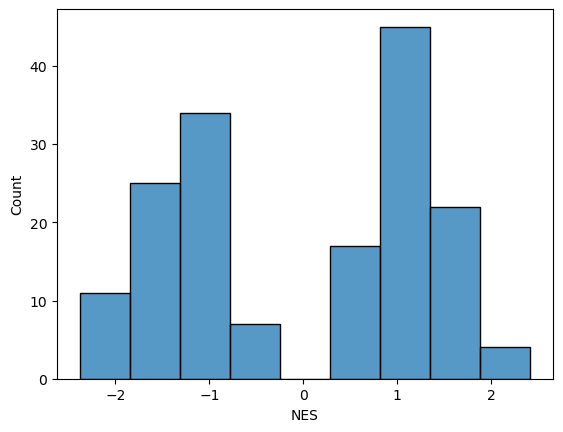

ciao prerank rows: 165 -> /Users/achechenina/projects/centenerians/results/data/pathway_gsea_compare/ciao_KEGG_HALLMARK_prerank_logfc.csv


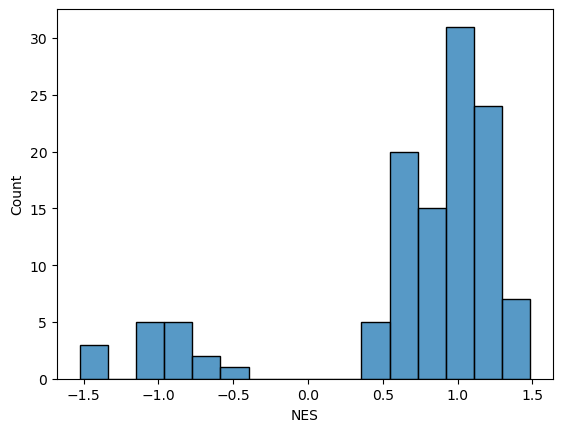

ukbb prerank rows: 118 -> /Users/achechenina/projects/centenerians/results/data/pathway_gsea_compare/ukbb_KEGG_HALLMARK_prerank_logfc.csv


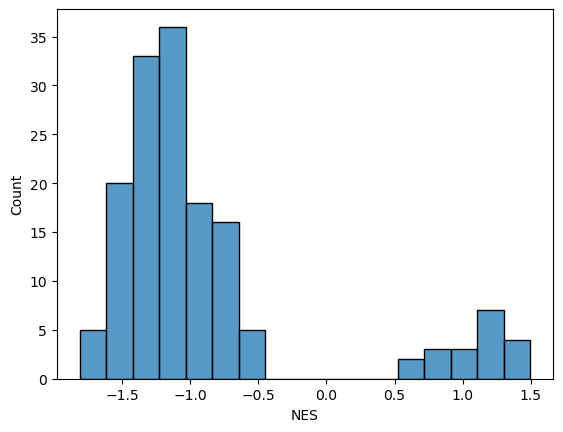

necs prerank rows: 152 -> /Users/achechenina/projects/centenerians/results/data/pathway_gsea_compare/necs_KEGG_HALLMARK_prerank_logfc.csv


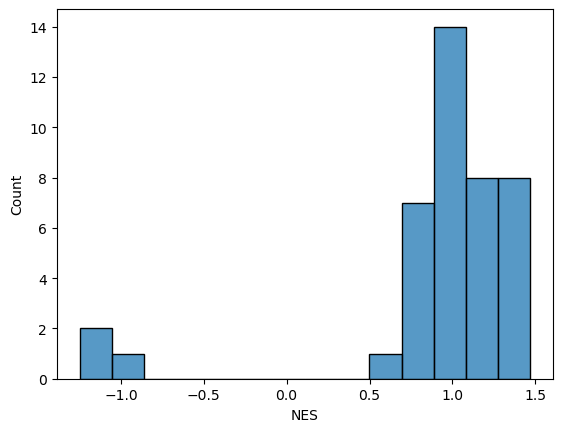

swiss100 prerank rows: 41 -> /Users/achechenina/projects/centenerians/results/data/pathway_gsea_compare/swiss100_KEGG_HALLMARK_prerank_logfc.csv


In [40]:
# --- Prerank GSEA (genes ranked by logFC / Age_Beta / log2 NECS FC); KEGG + Hallmark GMT gene sets ---
# Requires ``meta_dict`` from the previous cell (ciao, ukbb, necs, swiss100).

PRERANK_PARAMS = dict(
    gene_sets=COMBINED_GENE_SETS,
    permutation_num=1000,
    min_size=15,
    max_size=500,
    weight=1.0,
    threads=4,
    seed=42,
    no_plot=True,
    verbose=False,
)

for name, cfg in meta_dict.items():
    rnk = _build_prerank_logfc(cfg["data"], cfg["genecol"], cfg["log2fc_col"])
    out_csv = DATA_OUT / f"{name}_KEGG_HALLMARK_prerank_logfc.csv"
    tmp = DATA_OUT / f"_gsea_tmp_{name}"
    tmp.mkdir(exist_ok=True)
    pre = gseapy.prerank(
        rnk=rnk,
        outdir=str(tmp),
        **PRERANK_PARAMS,
    )
    # plot NES distribution
    sns.histplot(pre.res2d.NES)
    plt.show()
    plt.close()
    tab = pre.res2d.copy()
    if "Term" in tab.columns:
        tab["library"] = tab["Term"].map(_pathway_library)
    tab.to_csv(out_csv, index=False)
    print(name, "prerank rows:", len(tab), "->", out_csv)

<Axes: xlabel='NES', ylabel='Count'>

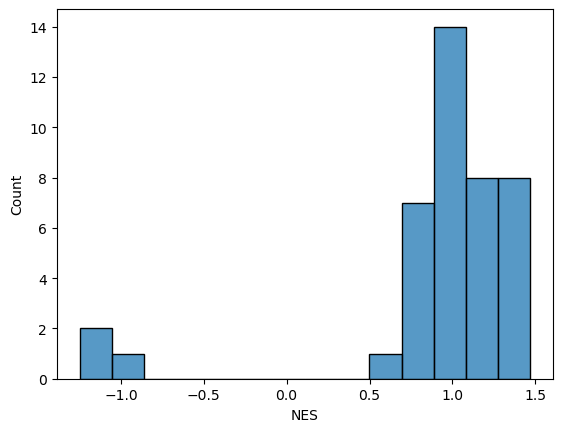

In [38]:
sns.histplot(pre.res2d.NES)

In [34]:
# --- Fisher exact per pathway (query = genes with padj/p < 0.25); BH-FDR over KEGG ∪ Hallmark; top 15 dotplots ---
for name, cfg in meta_dict.items():
    ftab = _fisher_kegg(cfg["data"], cfg["genecol"], cfg["padj_col"], COMBINED_LIB, sig_thresh=0.25)
    fcsv = DATA_OUT / f"{name}_KEGG_HALLMARK_fisher_exact.csv"
    ftab.to_csv(fcsv, index=False)
    print(name, "Fisher pathways:", len(ftab), "->", fcsv)
    _dotplot_top15(
        ftab,
        title=f"{name.upper()} — KEGG + Hallmark (Fisher, BH-FDR)",
        out_png=PLOT_OUT / f"{name}_KEGG_HALLMARK_fisher_dotplot_top15.png",
        top_n=15,
    )

ciao Fisher pathways: 235 -> /Users/achechenina/projects/centenerians/results/data/pathway_gsea_compare/ciao_KEGG_HALLMARK_fisher_exact.csv
Saved /Users/achechenina/projects/centenerians/results/plots/pathway_gsea_compare/ciao_KEGG_HALLMARK_fisher_dotplot_top15.png
ukbb Fisher pathways: 234 -> /Users/achechenina/projects/centenerians/results/data/pathway_gsea_compare/ukbb_KEGG_HALLMARK_fisher_exact.csv
Saved /Users/achechenina/projects/centenerians/results/plots/pathway_gsea_compare/ukbb_KEGG_HALLMARK_fisher_dotplot_top15.png
necs Fisher pathways: 233 -> /Users/achechenina/projects/centenerians/results/data/pathway_gsea_compare/necs_KEGG_HALLMARK_fisher_exact.csv
Saved /Users/achechenina/projects/centenerians/results/plots/pathway_gsea_compare/necs_KEGG_HALLMARK_fisher_dotplot_top15.png
swiss100 Fisher pathways: 199 -> /Users/achechenina/projects/centenerians/results/data/pathway_gsea_compare/swiss100_KEGG_HALLMARK_fisher_exact.csv
Saved /Users/achechenina/projects/centenerians/results